Images saved as f1_ypbpr.png and f1_rgb_back.png


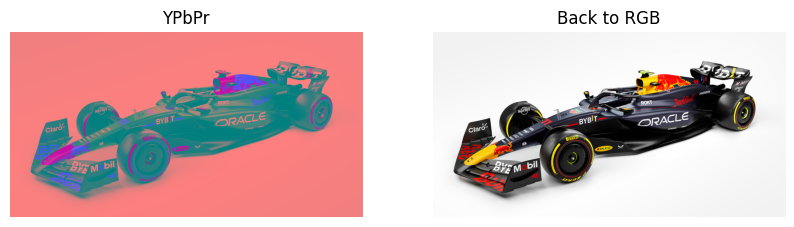

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r"C:\Users\user\OneDrive\Desktop\F1 car image.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Convert RGB to YPbPr ---
def rgb2ypbpr(img):
    img = img.astype(np.float32) / 255.0
    matrix = np.array([[0.299, 0.587, 0.114],
                       [-0.168736, -0.331264, 0.5],
                       [0.5, -0.418688, -0.081312]])
    ypbpr = img @ matrix.T
    ypbpr[:,:,1:] += 0.5  # shift Pb, Pr
    return ypbpr

# --- Convert YPbPr back to RGB ---
def ypbpr2rgb(ypbpr):
    ypbpr = ypbpr.copy()
    ypbpr[:,:,1:] -= 0.5
    matrix = np.array([[1.0, 0.0, 1.402],
                       [1.0, -0.344136, -0.714136],
                       [1.0, 1.772, 0.0]])
    rgb = ypbpr @ matrix.T
    rgb = np.clip(rgb, 0.0, 1.0)
    return (rgb * 255).astype(np.uint8)

# Perform conversions
img_ypbpr = rgb2ypbpr(rgb)
img_rgb_back = ypbpr2rgb(img_ypbpr)

# --- Save images ---
cv2.imwrite("f1_ypbpr.png", (img_ypbpr * 255).astype(np.uint8))   # save YPbPr
cv2.imwrite("f1_rgb_back.png", cv2.cvtColor(img_rgb_back, cv2.COLOR_RGB2BGR))  # save restored RGB

print("Images saved as f1_ypbpr.png and f1_rgb_back.png")

# --- Display results ---
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_ypbpr); plt.title("YPbPr"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_rgb_back); plt.title("Back to RGB"); plt.axis("off")
plt.show()
